Imports

In [78]:
import sklearn
from sklearn.model_selection import train_test_split

In [79]:
import pandas as pd
import numpy as np

Load the real world dataset and display the structure

In [80]:
dataset = sklearn.datasets.load_diabetes( return_X_y=False, as_frame=False)

In [81]:
print(dataset.data[0])

[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
 -0.04340085 -0.00259226  0.01990749 -0.01764613]


In [82]:
print(dataset.target)

[151.  75. 141. 206. 135.  97. 138.  63. 110. 310. 101.  69. 179. 185.
 118. 171. 166. 144.  97. 168.  68.  49.  68. 245. 184. 202. 137.  85.
 131. 283. 129.  59. 341.  87.  65. 102. 265. 276. 252.  90. 100.  55.
  61.  92. 259.  53. 190. 142.  75. 142. 155. 225.  59. 104. 182. 128.
  52.  37. 170. 170.  61. 144.  52. 128.  71. 163. 150.  97. 160. 178.
  48. 270. 202. 111.  85.  42. 170. 200. 252. 113. 143.  51.  52. 210.
  65. 141.  55. 134.  42. 111.  98. 164.  48.  96.  90. 162. 150. 279.
  92.  83. 128. 102. 302. 198.  95.  53. 134. 144. 232.  81. 104.  59.
 246. 297. 258. 229. 275. 281. 179. 200. 200. 173. 180.  84. 121. 161.
  99. 109. 115. 268. 274. 158. 107.  83. 103. 272.  85. 280. 336. 281.
 118. 317. 235.  60. 174. 259. 178. 128.  96. 126. 288.  88. 292.  71.
 197. 186.  25.  84.  96. 195.  53. 217. 172. 131. 214.  59.  70. 220.
 268. 152.  47.  74. 295. 101. 151. 127. 237. 225.  81. 151. 107.  64.
 138. 185. 265. 101. 137. 143. 141.  79. 292. 178.  91. 116.  86. 122.
  72. 

Create a random permuntation so I can make sure that the model works and not only with single permuntation

In [83]:
X = dataset.data
Y = dataset.target

In [84]:
#set seed for this to be reproducible
np.random.seed(42)

n = X.shape[0]
perm = np.random.permutation(n)

X = X[perm]
Y = Y[perm]

In [85]:
print(X[0])

[ 0.04534098 -0.04464164 -0.00620595 -0.01599898  0.1250187   0.1251981
  0.019187    0.03430886  0.03243232 -0.0052198 ]


Create the training, test split

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [87]:
X_train.shape, y_train.shape


((353, 10), (353,))

In [88]:
X_test.shape, y_test.shape

((89, 10), (89,))

The trouble I ran into was the dataset not being expressive enough, so I'm creating polynomial features

In [89]:
# Adding x^^2 and x1x2 features
X_train = np.c_[X_train, X_train[:, 0]**2, X_train[:, 1]**2, X_train[:, 0]*X_train[:, 1]]
X_test = np.c_[X_test, X_test[:, 0]**2, X_test[:, 1]**2, X_test[:, 0]*X_test[:, 1]]

Add a bias (intercept) to the datapoints so the weights are not being updated that harshly

In [90]:
def add_bias(X):
    return np.c_[np.ones(X.shape[0]), X]

X_train_b = add_bias(X_train)
X_test_b = add_bias(X_test)

Determine simple functions

In [91]:
#Error

def calculcateError( label, predi):
  predictionError = ( predi - label ) ** 2
  ''' print( predictionError) '''
  return predictionError

def simpleError( label, predi):
  predictionError =  predi - label
  ''' print( predictionError) '''
  return predictionError

def sumError(y_pred, labels):
  totalModelError = 0
  for i in range(len(y_pred)):

    error  = calculcateError( labels[i], y_pred[i])
    totalModelError += error

  return totalModelError

def simpleSumError(y_pred, labels):
  totalModelError = 0
  for i in range(len(y_pred)):

    error  = simpleError( labels[i], y_pred[i])
    totalModelError += error

  return totalModelError


# crude and easy implementation of a prediction
def predict(X, w):
    return X @ w




''' sumError(y_pred) '''



' sumError(y_pred) '

Ridge

In [92]:
# ridge addon for weights
def getRidgePenalty(alpha, w):
    total = 0
    for i in range(len(w)):
      total += (w[i] ** 2)


    return alpha * total


def getRidgeGradient(alpha, w):

  reg = 2 * alpha * w
  reg[0] = 0
  return reg

In [93]:
''' def gradientDescent(learningRate, X,y):

    m_gradient = 0
    b_gradient = 0
    n = len(X)

  return upWeights '''

def getFeatureBlame( X, y, y_pred):

    # figure out how each feature contributed to those errors
    return (X.T @ (y_pred - y))

In [94]:
# L2, ridge
def ridge(X, y):
  # Regulation strength or penalty strength
  alpha = 0
  learningRate = 0.001
  prev_loss = float("inf")

  iterations = 10000

  m, n = X.shape

  # Create weights
  w = np.zeros(n)

  for i in range(iterations):
    y_pred = predict(X, w)


    loss  = sumError(y_pred, y)

    '''   if loss >= prev_loss:
      learningRate *= 0.8
      prev_loss = loss '''

    gradient = (2 / m) *  getFeatureBlame(X, y ,y_pred) + getRidgeGradient(alpha, w)
    '''   print(gradient) '''
    # update weights
    w = w - learningRate * gradient


    ''' print(w ) '''
  return w

ridgeWeights = ridge(X_train_b, y_train)


testPredictions = predict(X_test_b, ridgeWeights)
print(sumError(testPredictions, y_test))

345328.22850624035


In [98]:
for i in range(10):
  print("Error for " + str(i)
        + ": " + str(calculcateError(testPredictions[i], y_test[i]))
        + ", Prediction: " + str(testPredictions[i])
        + ", label : " +str( y_test[i]))

Error for 0: 141.89471400333778, Prediction: 152.91195676634774, label : 141.0
Error for 1: 2413.382092100584, Prediction: 158.12618540147997, label : 109.0
Error for 2: 12699.71143937144, Prediction: 168.30700359218662, label : 281.0
Error for 3: 9182.891129701105, Prediction: 167.1725971879593, label : 263.0
Error for 4: 8539.195785639065, Prediction: 153.4077690761933, label : 61.0
Error for 5: 1881.8454851735871, Prediction: 156.61975697193955, label : 200.0
Error for 6: 17957.05494374947, Prediction: 157.996063700541, label : 292.0
Error for 7: 6697.013501008179, Prediction: 154.83528273922062, label : 73.0
Error for 8: 3751.9714572956727, Prediction: 144.25333833592805, label : 83.0
Error for 9: 1951.2733675059817, Prediction: 160.17322002645926, label : 116.0


In [96]:
print(ridgeWeights)

[154.82158267  11.18261702   4.44914074  43.84192319  30.48791342
  13.31976266   9.45247621 -28.52371315  30.37767404  42.35026961
  26.01664109   0.25179929   0.37714113   0.18220339]


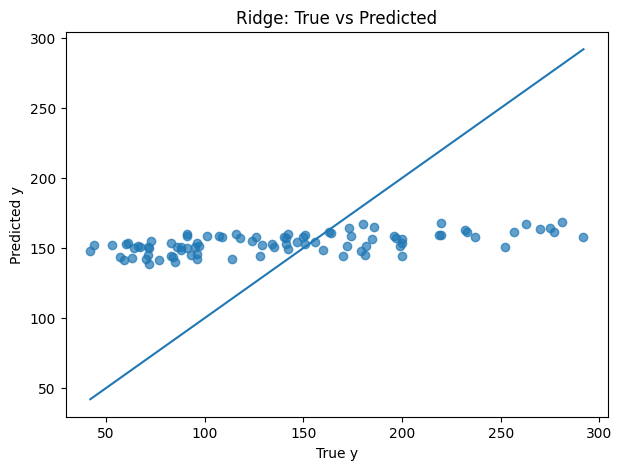

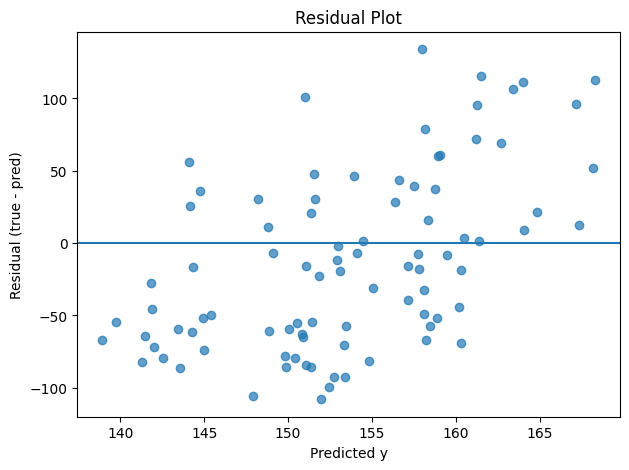

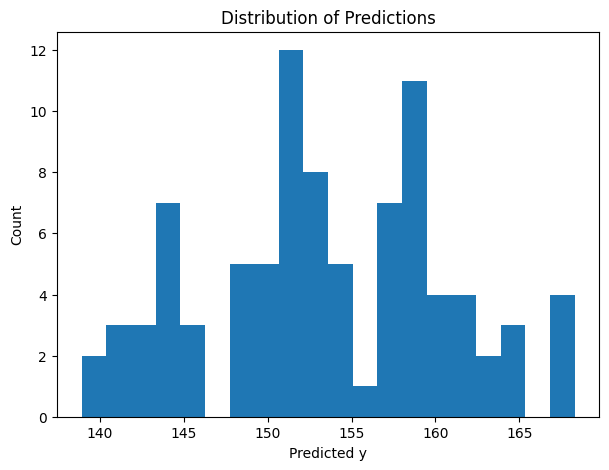

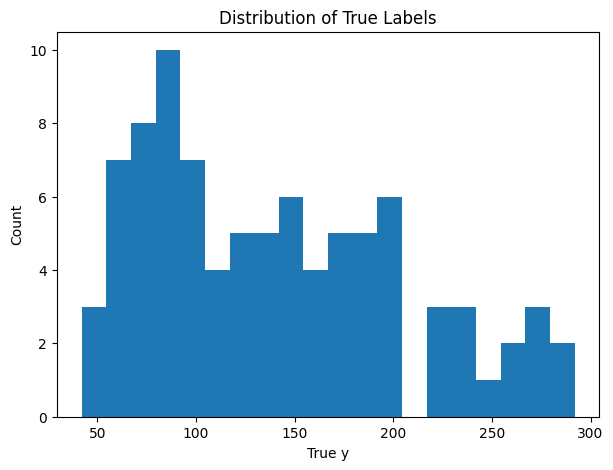

In [97]:
import numpy as np
import matplotlib.pyplot as plt

# predictions from your ridge model
ridgeWeights = ridge(X_train_b, y_train)
testPredictions = predict(X_test_b, ridgeWeights)

# make sure these are numpy arrays
y_test_np = np.asarray(y_test)
pred_np = np.asarray(testPredictions)

# 1) True vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test_np, pred_np, alpha=0.7)
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("Ridge: True vs Predicted")
plt.plot([y_test_np.min(), y_test_np.max()],
         [y_test_np.min(), y_test_np.max()])
plt.show()

# 2) Residual plot
residuals = y_test_np - pred_np

plt.figure(figsize=(7, 5))
plt.scatter(pred_np, residuals, alpha=0.7)
plt.axhline(0)
plt.xlabel("Predicted y")
plt.ylabel("Residual (true - pred)")
plt.title("Residual Plot")
plt.show()

# 3) Histogram of predictions
plt.figure(figsize=(7, 5))
plt.hist(pred_np, bins=20)
plt.xlabel("Predicted y")
plt.ylabel("Count")
plt.title("Distribution of Predictions")
plt.show()

# 4) Histogram of true values
plt.figure(figsize=(7, 5))
plt.hist(y_test_np, bins=20)
plt.xlabel("True y")
plt.ylabel("Count")
plt.title("Distribution of True Labels")
plt.show()